
# Lab 4: FDM-diffusion

#Por: Leonardo Ortega Trujillo - 100112197

 **Exercise** : Heat diffusion in a plate using FDM

Let's consider a rectangular heat-conducting plate with sides of lengths $a=20$ mm and $b=10$ mm. It has borders a temperature as is shown in figure.  The flat faces are isolated, so they can't lose head to the surroundings. The material is aluminum with thermal diffusivity $D\approx 84\, mm^2/s$.

<img src="https://github.com/anferivera/Fisica_Computacional_1/raw/main/Sesiones/PDE/figures/plato_coductor2.jpg" alt="Texto alternativo" width="400" height="400">

1. Use **FDM** to solve the *static solution* for this system for $f(x)=100\,\sin(3\pi x/a)$ C.
2. Compare the *static solution* with the analytical one.
2. Use **FDM** to found the temperature, i.e., solve the diffusion equation for some times.
3. Do a gif for the temperature in time (bonus!)

In [16]:
import numpy as np
import pandas as pd
import time as tm
import matplotlib.pyplot as plt
import math as mt
from IPython.display import HTML
import matplotlib.animation as animation
from IPython.display import Image, display

Ejecutando 3359 pasos de tiempo con dt = 0.000030 s...


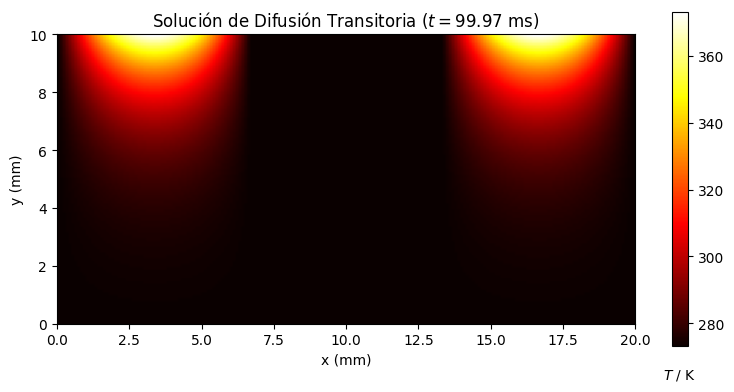

In [17]:
#1)
# Parámetros del dominio y material para la ecuación de difusión
a = 20.0  # Eje x (mm)
b = 10.0  # Eje y (mm)
dx = dy = 0.1  # Intervalos en x, y (mm)
D = 84   # Difusividad térmica del material (mm^2/s)

Tcool, Thot = 273.15, 373.15  # Temperaturas de referencia (K)

nx = int(a / dx) + 1
ny = int(b / dy) + 1

dx2, dy2 = dx * dx, dy * dy
dt = dx2 * dy2 / (2 * D * (dx2 + dy2))  # Paso de tiempo máximo permitido por estabilidad

# Definir el tiempo total de simulación
t_final = 0.1  # segundos
n_steps = int(t_final / dt)

# 2. Matriz inicial de temperatura con Tcool
T_initial = np.full((ny, nx), Tcool)

# Vector x para evaluar la función en el borde superior
x = np.linspace(0, a, nx)

# Condición de frontera superior (y = b)
f_x = Tcool + (Thot - Tcool) * np.sin(3 * np.pi * x / a)
T_initial[-1, :] = f_x

# 3. Solución por Diferencias Finitas (Ecuación de Difusión Transitoria - Método FTCS)
def Diffusion2D_FTCS(T_ini, n_steps, D, dt, dx2, dy2, f_x_top):
    T = T_ini.copy()

    # Coeficientes para la discretización espacial
    rx = D * dt / dx2
    ry = D * dt / dy2

    for n in range(n_steps):
        T_old = T.copy()

        # Actualización explícita en el tiempo para los puntos interiores
        T[1:-1, 1:-1] = T_old[1:-1, 1:-1] + \
            rx * (T_old[2:, 1:-1] - 2 * T_old[1:-1, 1:-1] + T_old[:-2, 1:-1]) + \
            ry * (T_old[1:-1, 2:] - 2 * T_old[1:-1, 1:-1] + T_old[1:-1, :-2])

        # Mantener la condición de frontera superior fija en cada paso de tiempo
        T[-1, :] = f_x_top

    return T

# ejecutar
print(f"Ejecutando {n_steps} pasos de tiempo con dt = {dt:.6f} s...")
T_final = Diffusion2D_FTCS(T_initial, n_steps, D, dt, dx2, dy2, f_x)

#gráfica
plt.figure(figsize=(8, 4))
im = plt.imshow(T_final, cmap='hot', origin='lower', extent=[0, a, 0, b],
                vmin=Tcool, vmax=Thot)

cbar = plt.colorbar(im)
cbar.ax.set_xlabel('$T$ / K', labelpad=15)

plt.title(f'Solución de Difusión Transitoria ($t = {n_steps*dt*1000:.2f}$ ms)')
plt.xlabel('x (mm)')
plt.ylabel('y (mm)')
plt.tight_layout()
plt.show()

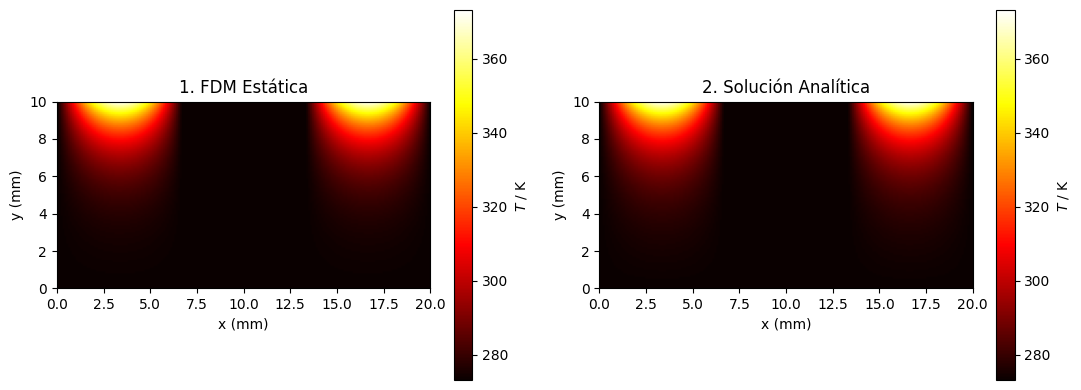

In [18]:
#2)
#solución estática previamente cálculada
u_estatico = T_final.copy()

#cálculo de solución analitica
u_analitico = 273.15*np.ones((ny, nx))

for i in range(nx):
    for j in range(ny):
        # Calculate coordinates correctly based on domain size and number of points
        x_coord = i * (a / (nx - 1))
        y_coord = j * (b / (ny - 1))
        # Fórmula matemática de la solución a la ecuación de Laplace
        # Assign to u_analitico[y_index, x_index] to match imshow orientation
        u_analitico[j,i] = 273.15 + 100*np.sin(3*np.pi*x_coord/a) * (np.sinh(3*np.pi*y_coord/a) / np.sinh(3*np.pi*b/a))

# Grafica: estática y la analítica juntas
fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

im1 = ax1.imshow(u_estatico, cmap="hot", origin="lower", extent=[0, a, 0, b], vmin=Tcool, vmax=Thot)
ax1.set_title("1. FDM Estática")
ax1.set_xlabel("x (mm)")
ax1.set_ylabel("y (mm)")
fig1.colorbar(im1, ax=ax1, label='$T$ / K')

im2 = ax2.imshow(u_analitico, cmap="hot", origin="lower", extent=[0, a, 0, b], vmin=273.15, vmax=373.15)
ax2.set_title("2. Solución Analítica")
ax2.set_xlabel("x (mm)")
ax2.set_ylabel("y (mm)")
fig1.colorbar(im2, ax=ax2, label='$T$ / K')

plt.tight_layout()
plt.show()

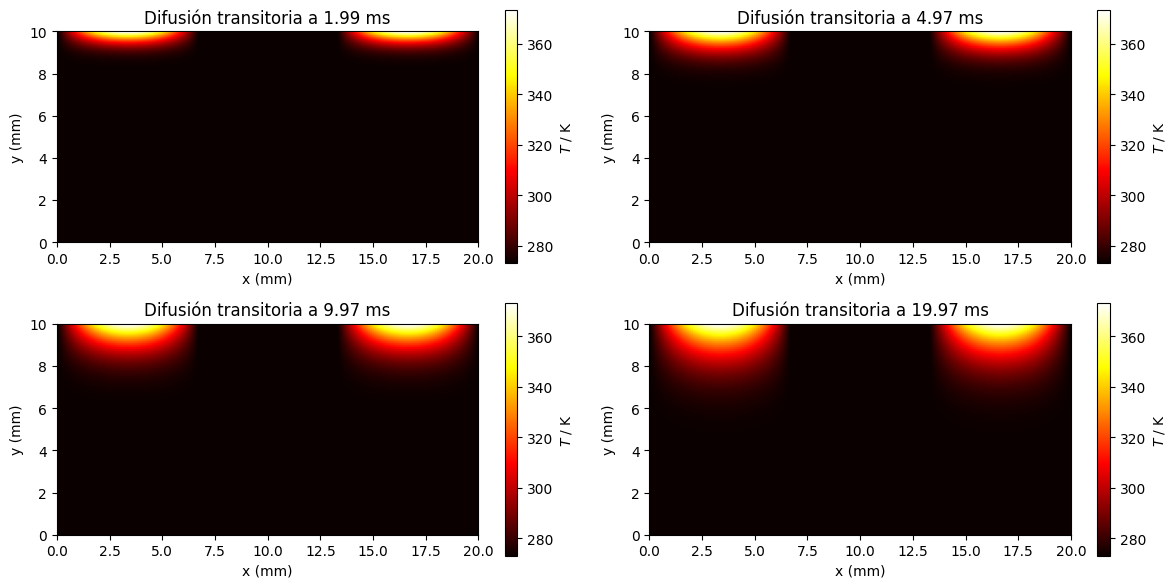

In [19]:
#3)
# Tiempos específicos en milisegundos para evaluar la evolución temporal
tiempos_objetivo_ms = [2.0, 5.0, 10.0, 20.0]
pasos_objetivo = [int((t * 1e-3) / dt) for t in tiempos_objetivo_ms]

# Matriz inicial de temperatura uniforme a Tcool
T = np.full((ny, nx), Tcool)

# Condición de frontera superior (y = b): perfil senoidal modulado entre Tcool y Thot
x = np.linspace(0, a, nx)
f_x = Tcool + (Thot - Tcool) * np.sin(3 * np.pi * x / a)
T[-1, :] = f_x  # Fijar el borde superior

# Coeficientes del método explícito FTCS
rx = D * dt / dx2
ry = D * dt / dy2

# Diccionario para almacenar las soluciones en los tiempos requeridos
resultados = {}
max_paso = max(pasos_objetivo)

# Simulación temporal iterativa
for n in range(max_paso + 1):
    if n in pasos_objetivo:
        t_actual_ms = (n * dt) * 1000
        resultados[t_actual_ms] = T.copy()

    if n == max_paso:
        break

    T_old = T.copy()

    # Actualización FTCS para los nodos interiores
    T[1:-1, 1:-1] = T_old[1:-1, 1:-1] + \
        rx * (T_old[2:, 1:-1] - 2 * T_old[1:-1, 1:-1] + T_old[:-2, 1:-1]) + \
        ry * (T_old[1:-1, 2:] - 2 * T_old[1:-1, 1:-1] + T_old[1:-1, :-2])

    # Restablecer condición de frontera superior constante en el tiempo
    T[-1, :] = f_x

# Gráficas para varios tiempos
fig, axes = plt.subplots(2, 2, figsize=(12, 6))
axes = axes.flatten()

for idx, (t_ms, T_img) in enumerate(resultados.items()):
    ax = axes[idx]
    im = ax.imshow(T_img, cmap='hot', origin='lower', extent=[0, a, 0, b],
                    vmin=Tcool, vmax=Thot)
    ax.set_title(f'Difusión transitoria a {t_ms:.2f} ms')
    ax.set_xlabel('x (mm)')
    ax.set_ylabel('y (mm)')
    fig.colorbar(im, ax=ax, label='$T$ / K')

plt.tight_layout()
plt.show()

In [ ]:
#4)

# Configuración temporal para la animación
t_total = 0.05  # Tiempo total simulado en segundos (50 ms)
total_steps = int(t_total / dt)
frame_interval = max(1, total_steps // 100)  # Capturar ~100 fotogramas para fluidez

# Matriz inicial de temperatura uniforme a Tcool
T = np.full((ny, nx), Tcool)

# Condición de frontera superior (y = b)
x = np.linspace(0, a, nx)
f_x = Tcool + (Thot - Tcool) * np.sin(3 * np.pi * x / a)
T[-1, :] = f_x

# Coeficientes del método explícito FTCS
rx = D * dt / dx2
ry = D * dt / dy2

frames_data = []
tiempos_ms = []

print("Simulando y recolectando fotogramas para el GIF...")
print(f"Paso de tiempo dt = {dt:.6f} s | Total de pasos: {total_steps}")
for n in range(total_steps + 1):
    if n % frame_interval == 0:
        frames_data.append(T.copy())
        tiempos_ms.append((n * dt) * 1000)

    if n == total_steps:
        break

    T_old = T.copy()

    # Actualización FTCS para los nodos interiores
    T[1:-1, 1:-1] = T_old[1:-1, 1:-1] + \
        rx * (T_old[2:, 1:-1] - 2 * T_old[1:-1, 1:-1] + T_old[:-2, 1:-1]) + \
        ry * (T_old[1:-1, 2:] - 2 * T_old[1:-1, 1:-1] + T_old[1:-1, :-2])

    # Mantener constante la frontera superior
    T[-1, :] = f_x

# Configuración de la figura para la animación
fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(frames_data[0], cmap='hot', origin='lower', extent=[0, a, 0, b],
                vmin=Tcool, vmax=Thot)

cbar = fig.colorbar(im, ax=ax)
cbar.ax.set_xlabel('$T$ / K', labelpad=15)

title_text = ax.set_title('')
ax.set_xlabel('x (mm)')
ax.set_ylabel('y (mm)')

# Función de actualización por fotograma
def update(i):
    im.set_array(frames_data[i])
    title_text.set_text(f'Difusión Transitoria del Calor - t = {tiempos_ms[i]:.2f} ms')
    return [im, title_text]

ani = animation.FuncAnimation(fig, update, frames=len(frames_data), interval=40, blit=True)

# Guardar la animación como archivo GIF utilizando PillowWriter
print("Generando y guardando el archivo GIF...")
gif_filename = 'temperatura_difusion.gif'
ani.save(gif_filename, writer='pillow', fps=25)
print(f"¡GIF guardado exitosamente como '{gif_filename}'!")

# Cerrar la figura estática de matplotlib para que no se encime con el GIF
plt.close(fig)

# Reproducir y visualizar el GIF directamente en la salida de la celda
print("Reproduciendo el GIF en tiempo real:")
display(Image(filename=gif_filename))


Simulando y recolectando fotogramas para el GIF...
Paso de tiempo dt = 0.000030 s | Total de pasos: 1679
Generando y guardando el archivo GIF...
